In [54]:
import numpy as np
import pandas as pd
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [55]:
class Node:
    def __init__(self, feature=None, value=None, results=None, children=None):
        self.feature = feature
        self.value = value
        self.results = results
        self.children = children or {}

In [56]:
class ID3DecisionTree:
    def __init__(self):
        self.root = None

    def entropy(self, labels):
        counts = Counter(labels)
        total = len(labels)
        if total == 0:
            return 0
        return -sum((count/total)*np.log2(count/total) for count in counts.values() if count > 0)

    def information_gain(self, data, labels, feature):
        total_entropy = self.entropy(labels)
        values = np.unique(data[:, feature])
        weighted_entropy = 0
        for value in values:
            subset_mask = (data[:, feature] == value)
            subset_labels = labels[subset_mask]
            weighted_entropy += (len(subset_labels)/len(labels)) * self.entropy(subset_labels)
        return total_entropy - weighted_entropy

    def best_feature(self, data, labels):
        features = range(data.shape[1])
        gains = [self.information_gain(data, labels, feature) for feature in features]
        best_idx = np.argmax(gains)
        return best_idx if gains[best_idx] > 0 else None

    def build_tree(self, data, labels):
        if len(np.unique(labels)) == 1:
            return Node(results=labels[0])
        
        if data.shape[1] == 0:
            return Node(results=Counter(labels).most_common(1)[0][0])
        
        best = self.best_feature(data, labels)
        if best is None:
            return Node(results=Counter(labels).most_common(1)[0][0])
        
        root = Node(feature=best)
        values = np.unique(data[:, best])
        for value in values:
            mask = (data[:, best] == value)
            subset_data = np.delete(data[mask], best, axis=1)
            subset_labels = labels[mask]
            root.children[value] = self.build_tree(subset_data, subset_labels)
        return root

    def fit(self, data, labels):
        self.root = self.build_tree(np.array(data), np.array(labels))

    def predict_sample(self, node, sample):
        if node.results is not None:
            return node.results
        value = sample[node.feature]
        if value in node.children:
            child_sample = np.delete(sample, node.feature)
            return self.predict_sample(node.children[value], child_sample)
        return Counter(self.root.results).most_common(1)[0][0] if self.root.results is not None else None

    def predict(self, data):
        return [self.predict_sample(self.root, np.array(sample)) for sample in data]

    def visualise_tree(self, node=None, graph=None, parent_name=None, edge_label=''):
        if graph is None:
            graph = nx.DiGraph()
            node = self.root

        if node.feature is None:
            node_label = f'Class: {node.results}'
        else:
            node_label = f'Feature {node.feature}'
        
        graph.add_node(node_label)

        if parent_name is not None:
            graph.add_edge(parent_name, node_label, label=str(edge_label))
        
        for value, child in node.children.items():
            self.visualise_tree(child, graph, node_label, value)
        return graph

    def plot_tree(self):
        graph = self.visualise_tree()
        pos = nx.spring_layout(graph, seed=42)
        edge_labels = {(u, v): d['label'] for u, v, d in graph.edges(data=True)}

        plt.figure(figsize=(12, 8))
        nx.draw(graph, pos, with_labels=True, node_color='lightblue', 
                edge_color='gray', node_size=3000, font_size=10, arrows=True)
        nx.draw_networkx_edge_labels(graph, pos, edge_labels, font_size=8)
        plt.title('ID3 Decision Tree')
        plt.show()

In [57]:
# Standard PlayTennis dataset (14 rows)
data = np.array([
    ['sunny', 'hot', 'high', 'weak'],
    ['sunny', 'hot', 'high', 'strong'],
    ['overcast', 'hot', 'high', 'weak'],
    ['rain', 'mild', 'high', 'weak'],
    ['rain', 'cool', 'normal', 'weak'],
    ['rain', 'cool', 'normal', 'strong'],
    ['overcast', 'mild', 'high', 'weak'],
    ['overcast', 'cool', 'normal', 'weak'],
    ['rain', 'mild', 'normal', 'weak'],
    ['sunny', 'mild', 'normal', 'strong'],
    ['sunny', 'mild', 'normal', 'weak'],
    ['overcast', 'mild', 'high', 'strong'],
    ['overcast', 'hot', 'normal', 'weak'],
    ['rain', 'mild', 'high', 'strong'],
], dtype=object)

labels = np.array(['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'])

# Encode categorical data
encoder = LabelEncoder()
for i in range(data.shape[1]):
    data[:, i] = encoder.fit_transform(data[:, i])

print('Encoded data shape:', data.shape)
print('Labels:', labels)

Encoded data shape: (14, 4)
Labels: ['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'No']


In [58]:
tree = ID3DecisionTree()
tree.fit(data, labels)
print('Tree trained!')

Tree trained!


In [59]:
# Test prediction on first sample
pred = tree.predict([data[0]])
print('Prediction for sample 0:', pred)

Prediction for sample 0: ['No']


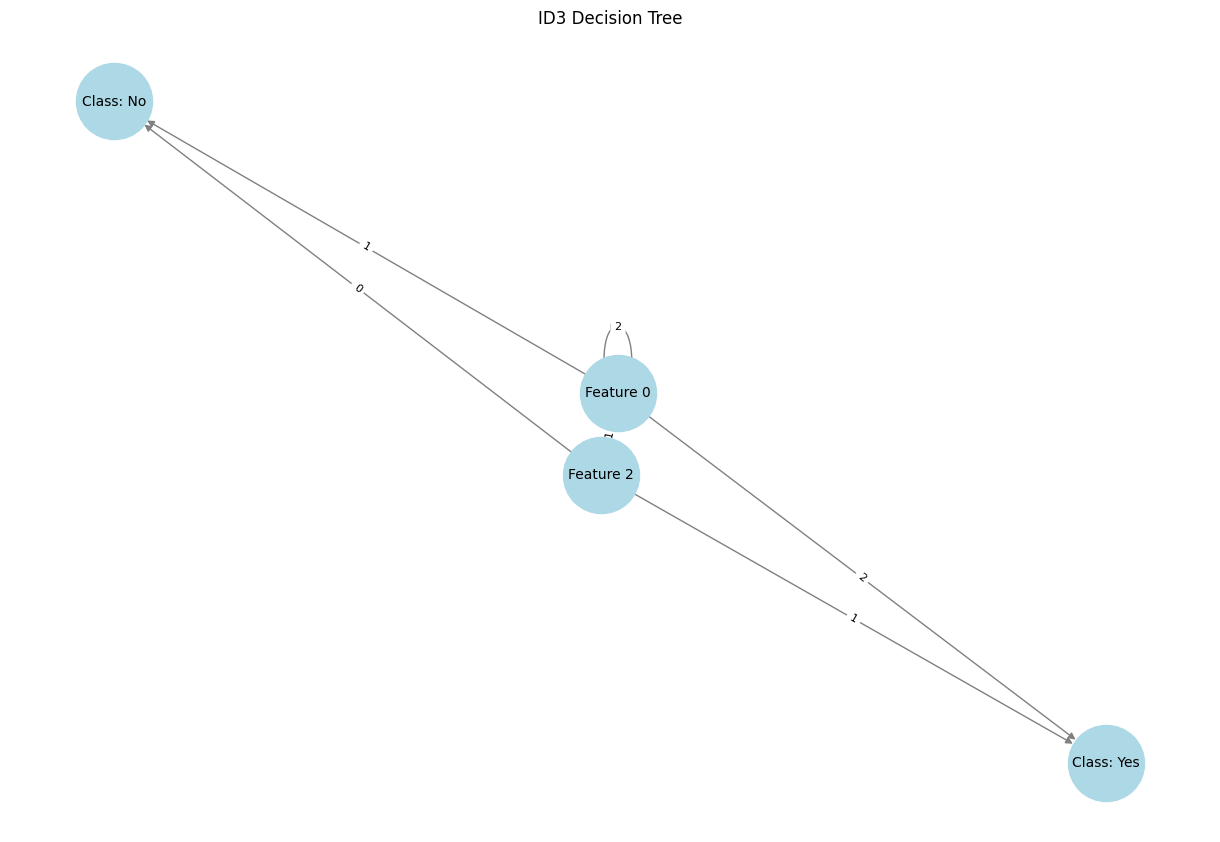

In [60]:
tree.plot_tree()